# Stroke Risk Models
This notebook trains and evaluates several models (Logistic Regression, RandomForest, DecisionTree, XGBoost) on the stroke dataset `healthcare-dataset-stroke-data.csv`.

In [1]:
import pandas as pd
import numpy as np

In [2]:
stroke_df = pd.read_csv('../data/healthcare-dataset-stroke-data.csv')
stroke_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
# Basic target and class balance check
print('Shape:', stroke_df.shape)
print('Stroke value counts:')
print(stroke_df['stroke'].value_counts(dropna=False))
print(stroke_df['stroke'].value_counts(normalize=True) * 100)

Shape: (5110, 12)
Stroke value counts:
stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [4]:
# Select useful features and prepare target
features = [
    'gender', 'age', 'hypertension', 'ever_married',
    'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status'
]
stroke_df = stroke_df[features + ['stroke']].copy()
# Ensure target is integer (0/1)
stroke_df['stroke'] = stroke_df['stroke'].astype(int)
stroke_df.dropna(subset=['age', 'avg_glucose_level'], inplace=True)
stroke_df.shape

(5110, 10)

In [5]:
ordinal_cols = []
nominal_cols = [
    'gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'
]
numeric_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension']  # Removed 'heart_disease'
stroke_df[numeric_cols].describe()

,age,avg_glucose_level,bmi,hypertension
count,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,106.147677,28.893237,0.097456
std,22.612647,45.283560,7.854067,0.296607
min,0.080000,55.120000,10.300000,0.000000
25%,25.000000,77.245000,23.500000,0.000000
50%,45.000000,91.885000,28.100000,0.000000
75%,61.000000,114.090000,33.100000,0.000000
max,82.000000,271.740000,97.600000,1.000000


In [6]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split

In [7]:
# Preprocessors: one for tree models (no scaling required but impute), and one for LR (impute + scale)
numeric_pipeline = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
numeric_pipeline_no_scale = make_pipeline(SimpleImputer(strategy='median'))

tree_preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'), nominal_cols),
    (numeric_pipeline_no_scale, numeric_cols)
)

lr_preprocessor = make_column_transformer(
    (OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_cols),
    (numeric_pipeline, numeric_cols)
)

X = stroke_df.drop('stroke', axis=1)
y = stroke_df['stroke']

In [8]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_lr_train = lr_preprocessor.fit_transform(X_train_raw)
X_lr_test = lr_preprocessor.transform(X_test_raw)

X_tree_train = tree_preprocessor.fit_transform(X_train_raw)
X_tree_test = tree_preprocessor.transform(X_test_raw)

In [9]:
# Train models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='liblinear')
rf = RandomForestClassifier(n_estimators=200, random_state=42)
dt = DecisionTreeClassifier(random_state=42)
# compute scale_pos_weight for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {scale_pos_weight:.2f}')
xboost = XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos_weight, random_state=42, use_label_encoder=False, eval_metric='logloss')

lr.fit(X_lr_train, y_train)
rf.fit(X_tree_train, y_train)
dt.fit(X_tree_train, y_train)
xboost.fit(X_tree_train, y_train)

print('Trained models: LogisticRegression, RandomForest, DecisionTree, XGBoost')

scale_pos_weight = 19.54
Trained models: LogisticRegression, RandomForest, DecisionTree, XGBoost


c:\Users\SAYAN GHOSH\Health_AI\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:11:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    metrics = {}
    metrics['model'] = name
    metrics['accuracy'] = accuracy_score(y_test, y_pred)
    metrics['precision'] = precision_score(y_test, y_pred, zero_division=0)
    metrics['recall'] = recall_score(y_test, y_pred, zero_division=0)
    metrics['f1'] = f1_score(y_test, y_pred, zero_division=0)
    try:
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(X_test)[:, 1]
            metrics['roc_auc'] = roc_auc_score(y_test, probs)
        else:
            metrics['roc_auc'] = np.nan
    except Exception:
        metrics['roc_auc'] = np.nan
    metrics['confusion_matrix'] = confusion_matrix(y_test, y_pred).tolist()
    return metrics

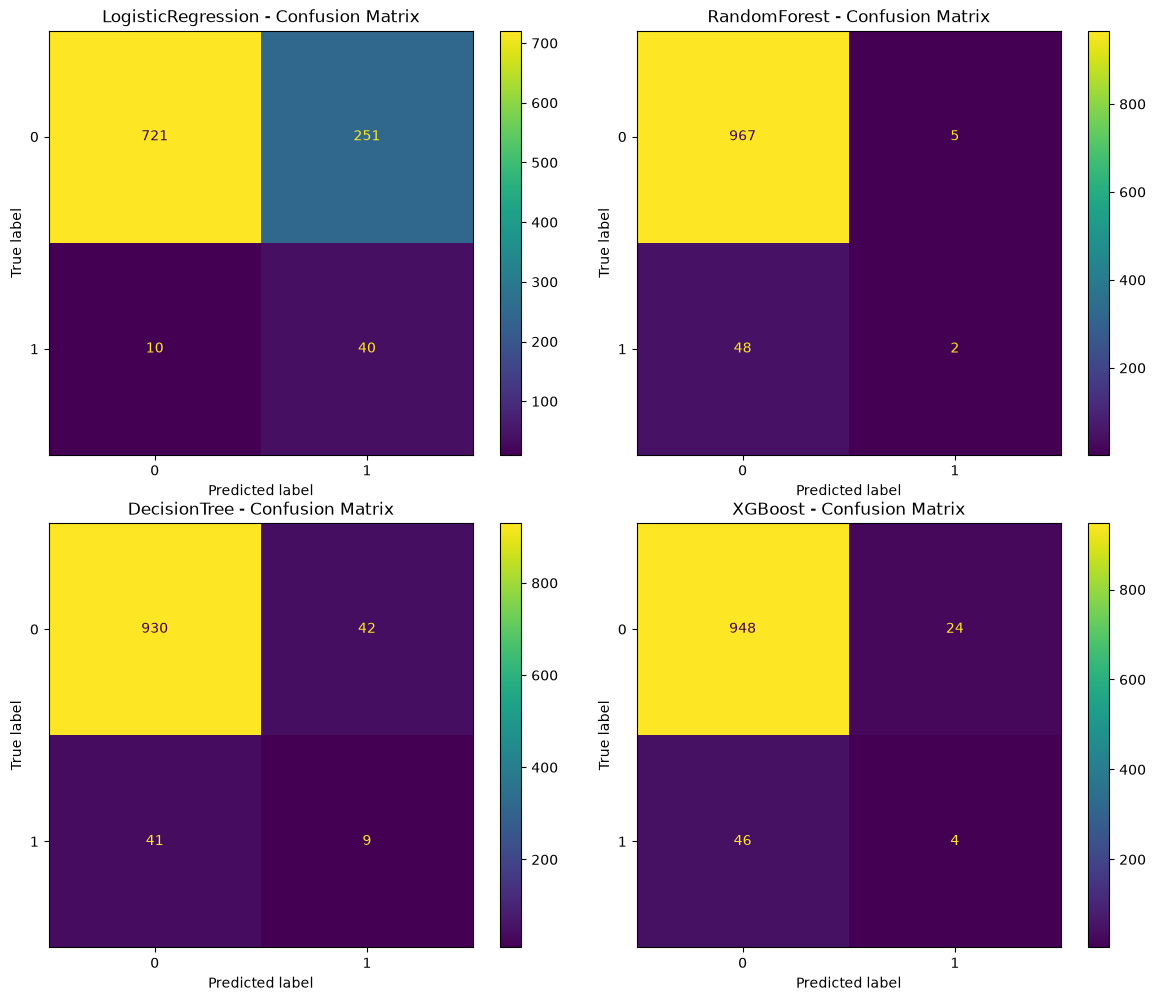

In [11]:
# Display confusion matrices
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
models = [
    ('LogisticRegression', lr, X_lr_test),
    ('RandomForest', rf, X_tree_test),
    ('DecisionTree', dt, X_tree_test),
    ('XGBoost', xboost, X_tree_test)
]
for idx, (name, model, X_test) in enumerate(models):
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[idx])
    axes[idx].set_title(f'{name} - Confusion Matrix')
plt.tight_layout()
plt.show()

In [12]:
# Summary table of metrics
results = []
results.append(evaluate_model('LogisticRegression', lr, X_lr_test, y_test))
results.append(evaluate_model('RandomForest', rf, X_tree_test, y_test))
results.append(evaluate_model('DecisionTree', dt, X_tree_test, y_test))
results.append(evaluate_model('XGBoost', xboost, X_tree_test, y_test))

rows = []
for r in results:
    rows.append({
        'model': r['model'],
        'accuracy': r['accuracy'],
        'precision': r['precision'],
        'recall': r['recall'],
        'f1': r['f1'],
        'roc_auc': r.get('roc_auc', np.nan)
    })
summary_df = pd.DataFrame(rows).set_index('model')
display(summary_df)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression,0.744618,0.137457,0.80,0.234604,0.842140
RandomForest,0.948141,0.285714,0.04,0.070175,0.771584
DecisionTree,0.918787,0.176471,0.18,0.178218,0.568395
XGBoost,0.931507,0.142857,0.08,0.102564,0.746379


In [13]:
# Threshold tuning for Logistic Regression
y_prob = lr.predict_proba(X_lr_test)[:, 1]
thresholds = [0.05, 0.1, 0.2, 0.3, 0.5]
from sklearn.metrics import precision_score, recall_score, f1_score
rows = []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    rows.append({'threshold': t, 'precision': prec, 'recall': rec, 'f1': f1})
thr_df = pd.DataFrame(rows).set_index('threshold')
display(thr_df)

,precision,recall,f1
threshold,,,
0.05,0.062104,0.98,0.116806
0.10,0.075617,0.98,0.140401
0.20,0.082852,0.86,0.151142
0.30,0.096998,0.84,0.173913
0.50,0.137457,0.80,0.234604


In [14]:
# Final summary: pick threshold and show final metrics for LR
final_threshold = 0.1
y_pred_final = (y_prob >= final_threshold).astype(int)
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_prob)
recall = recall_score(y_test, y_pred_final, zero_division=0)
precision = precision_score(y_test, y_pred_final, zero_division=0)
f1 = f1_score(y_test, y_pred_final, zero_division=0)
final_summary = pd.DataFrame({
    'metric': ['roc_auc', 'precision', 'recall', 'f1', 'threshold'],
    'value': [roc_auc, precision, recall, f1, final_threshold]
}).set_index('metric')
display(final_summary)
print('Final Stroke Model: Balanced Logistic Regression')
print(f'ROC-AUC = {roc_auc:.2f}')
print(f'Recall (threshold={final_threshold}) = {recall:.2f}')

,value
metric,
roc_auc,0.842140
precision,0.075617
recall,0.980000
f1,0.140401
threshold,0.100000


Final Stroke Model: Balanced Logistic Regression
ROC-AUC = 0.84
Recall (threshold=0.1) = 0.98


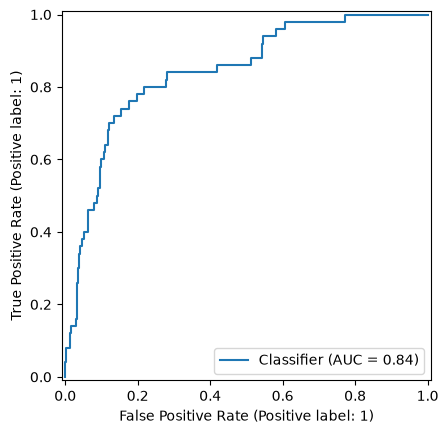

In [15]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)

In [16]:

import os
import joblib

MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

joblib.dump(
    lr,
    os.path.join(MODELS_DIR, "stroke_model.pkl")
)

joblib.dump(
    lr_preprocessor,
    os.path.join(MODELS_DIR, "stroke_preprocessor.pkl")
)

joblib.dump(
    final_threshold,
    os.path.join(MODELS_DIR, "stroke_threshold.pkl")
)

joblib.dump(
    X_train_raw.sample(1000, random_state=42),
    os.path.join(MODELS_DIR, "stroke_background.pkl")
)

print("Stroke model saved successfully!")

Stroke model saved successfully!
